# Perp Funding Rates — when longs get greedy, is a flush coming? 🪙
### Reading the crowd's leverage off the funding rate, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

A crypto **perpetual swap** ('perp') is a futures contract with no expiry date. To keep its price glued to the real spot price, exchanges make traders pay each other a small fee every 8 hours — the **funding rate**. When lots of people are aggressively *long* and levered, the perp trades a touch above spot, funding goes **positive**, and the longs pay the shorts. When everyone has capitulated and gone short, funding goes **negative** and the shorts pay.

So funding is a live read on **how the crowd is positioned**. The folklore: when funding runs *hot* (very positive), the longs are over-crowded and over-levered — and a **flush** (a sharp drop that liquidates them) is due. That makes hot funding a **contrarian** signal: fade the crowd.

We'd love to test that on the real tape. We **can't** — and that turns out to be the whole story.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from perp_funding_rate import data, strategy as st

# The reproducible core is SYNTHETIC — funding history is not free. The panel is deterministic
# (seed 585), so every number below reproduces exactly, offline.
BETA = -0.012
PANEL, TRUTH = data.synthetic_panel(contrarian_beta=BETA)
print(f"synthetic funding panel: {len(PANEL)} periods, planted contrarian_beta={BETA}, "
      f"fp {data.fingerprint(PANEL)}")

# The BTC/ETH PRICE tape (free) — loaded ONLY to make the missing-funding limitation concrete.
PX = data.fetch_btc_eth_prices(fetch=False)
HAVE_PX = not PX.empty
print("free BTC/ETH price tape present:", HAVE_PX,
      "" if not HAVE_PX else f"({len(PX)} rows, funding-rate tape is NOT free -> synthetic core)")


synthetic funding panel: 2000 periods, planted contrarian_beta=-0.012, fp 8121108453d2
free BTC/ETH price tape present: True (3102 rows, funding-rate tape is NOT free -> synthetic core)


## The answer first 🎯

| Question | Answer |
|---|---|
| Is the 'hot funding → flush' idea plausible? | **Yes.** It's a well-liked crypto-desk story with real mechanics behind it — funding really does track how levered the crowd is. |
| Did we prove it on the real market? | **No — we *can't*.** BTC/ETH *prices* are free, but the historical **funding-rate tape** (the whole signal) is locked behind **paid** exchange APIs. No funding data → no real test. |
| So what *did* we do? | Built a **synthetic** world where we *plant* the effect, and showed our engine catches it cleanly — and stays silent when nothing is planted. |
| Could you trade it if it were real? | **Barely.** It's the highest-turnover trade around (rebalance every 8 hours), and the short leg literally *pays* the funding it's betting on. |

> The honest verdict: the idea is plausible, the machinery works, but the data that would make it a **real** result isn't free — so we cap it below `REAL` and say so out loud.

## 1 · The claim

> *"When perpetual-futures funding rates run hot, longs are over-leveraged and due for a flush."* — crypto-desk folklore (Coinglass funding heatmaps, exchange & data-vendor research).

Why it's tempting: funding is one of the cleanest *positioning* gauges in any market. In stocks you guess at crowding; in crypto perps the exchange literally *charges* the crowded side. If the levered longs are all on one boat, a small wobble can cascade into forced liquidations — a flush. Fade the hot funding, buy the cold panic.

## 2 · So what?

If it worked, it'd be a rare thing: a *positioning* signal you can read off a public number, on the most liquid 24/7 market there is. It would also say something deep — that crowds in crypto are so reflexive that their own leverage predicts their own undoing. The desk has poked at crypto's price and calendar and sentiment signals already ([133](../../133-crypto-seasonality/), [175](../../175-crypto-weekend/), [210](../../210-crypto-trend/), [251](../../251-crypto-reversal/), [325](../../325-crypto-fear-greed/)); this is the one whose whole input is the *funding rate* — and that's exactly the input we can't get for free.

## 3 · How would we even know?

1. **Get the funding tape.** For each 8-hour period, the funding rate.
2. **Mark 'hot' and 'cold'.** Standardize funding against its recent history, so 'hot' means unusually high *right now*.
3. **Look forward.** After hot funding, did the price fall (a flush)? After cold funding, did it bounce? The contrarian claim says yes.

The catch that sinks the whole thing: **step 1 isn't free.** yfinance gives us BTC/ETH *prices* — but funding history lives behind paid exchange APIs (Binance, Bybit, Coinglass, Amberdata). Let's *see* the free price tape, then face the gap:

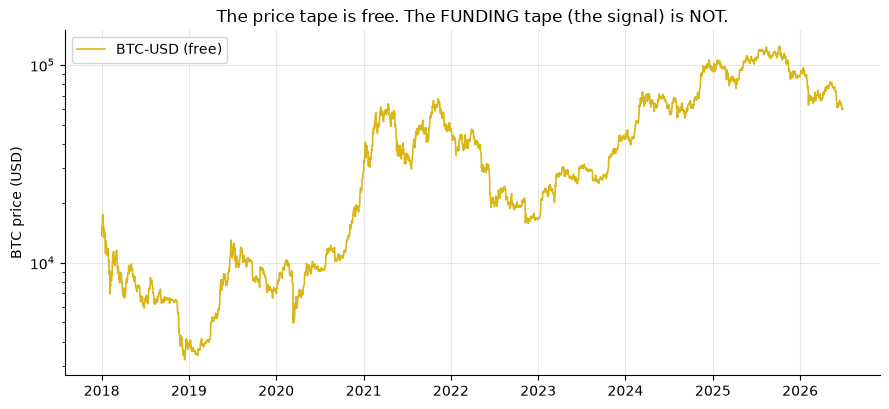

We have 3102 daily BTC/ETH closes -> but ZERO funding-rate history.


In [2]:
if HAVE_PX:
    fig, ax = plt.subplots(figsize=(9, 4.2))
    ax.plot(PX.index, PX['BTC-USD'], color=AMBER, lw=1.2, label='BTC-USD (free)')
    ax.set_ylabel('BTC price (USD)'); ax.set_yscale('log')
    ax.set_title('The price tape is free. The FUNDING tape (the signal) is NOT.')
    ax.legend(loc='upper left'); plt.tight_layout(); plt.show()
    print('We have', len(PX), 'daily BTC/ETH closes -> but ZERO funding-rate history.')
else:
    print('price cache absent (offline) — the point stands: funding history is not free.')

That price line is *all* a no-key stack gets. The funding rate — the entire signal — isn't in it. So we do the only honest thing: build a **synthetic** funding world where we control the truth, prove the engine works there, and refuse to claim a real result we can't earn.

*Timing note:* in the synthetic world the funding rate at each period is paired with the **next** period's returns — we never let the future leak into the signal.

## 4 · The teardown — the synthetic world

We build a made-up but realistic funding series (it drifts and mean-reverts, like real funding) and **plant** a contrarian effect: hot funding really does lead to lower forward returns. Then we sort periods into a *hot* fifth and a *cold* fifth and compare what happened next.

> ⚙️ **Everything below is synthetic** (a planted effect), *not* the market. It shows what a *real* signal would look like — and proves our detector isn't blind.

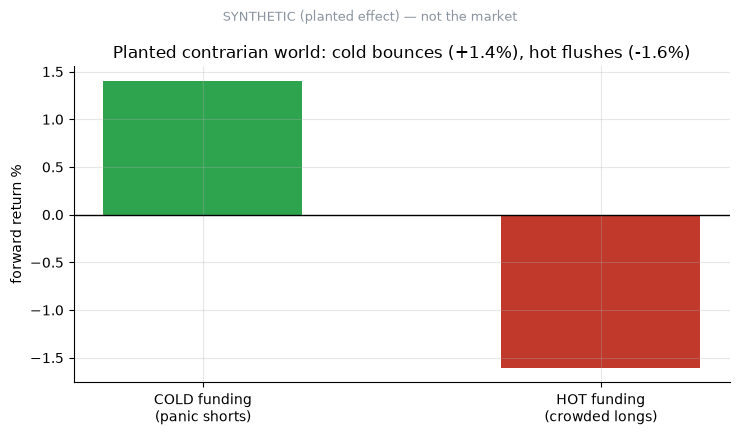

Cold +1.4%  vs  Hot -1.6%  ->  spread +3.0% (t +8.08)


In [3]:
b = st.tail_buckets(PANEL); ls = st.long_short_tstat(b)
cold_m, hot_m, spr, t = b['cold_mean']*100, b['hot_mean']*100, b['spread']*100, ls['t']
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['COLD funding\n(panic shorts)','HOT funding\n(crowded longs)'],
       [cold_m, hot_m], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f'Planted contrarian world: cold bounces (+{cold_m:.1f}%), hot flushes ({hot_m:.1f}%)')
fig.suptitle('SYNTHETIC (planted effect) — not the market', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'Cold +{cold_m:.1f}%  vs  Hot {hot_m:.1f}%  ->  spread {spr:+.1f}% (t {t:+.2f})')

On the planted tape the contrarian trade works by design: the cold-funding fifth bounced **+1.4%**, the hot-funding fifth flushed **-1.6%**, a spread of **+3.01%** (*t* **+8.08**). That's what a *real* funding signal would look like — clean and strong.

**But does our engine only ever say 'yes'?** The crucial test: turn the effect **off** (plant nothing) and check it goes quiet.

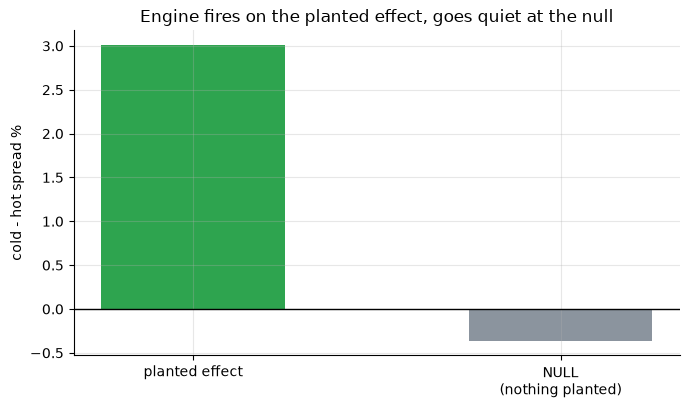

planted spread +3.0% (t +8.08)  |  null spread -0.4% (t -0.98)


In [4]:
pn, _ = data.synthetic_panel(contrarian_beta=0.0)
bn = st.tail_buckets(pn); lsn = st.long_short_tstat(bn)
spr_planted = st.tail_buckets(PANEL)['spread']*100
spr_null = bn['spread']*100
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['planted effect','NULL\n(nothing planted)'], [spr_planted, spr_null],
       color=[GREEN, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('cold - hot spread %')
ax.set_title('Engine fires on the planted effect, goes quiet at the null')
plt.tight_layout(); plt.show()
print(f'planted spread {spr_planted:+.1f}% (t {st.long_short_tstat(st.tail_buckets(PANEL))["t"]:+.2f})  |  '
      f'null spread {spr_null:+.1f}% (t {lsn["t"]:+.2f})')

Good — at the null the spread collapses toward zero (*t* ≈ -0.98, inside the noise band). The detector isn't a yes-machine: it fires on a real planted effect and stays quiet when there's nothing there. So if the market signal were real, we'd catch it. We just can't point the engine at a real funding tape.

## 5 · The verdict

- **Signal — None.** Not because the idea is bad — because we **cannot test it for real**. Funding history isn't free, so there's no real number, and the desk only stamps `REAL` when a real tape clears the bar. The synthetic control proves the engine works; that earns respect, not a `REAL`.
- **Tradability — Mirage.** Even granting the effect, it's an 8-hourly rebalance and the short leg *pays* the funding it trades on. Costs eat it.

## 6 · Could you actually trade it?

Barely, even in the best case. The signal refreshes every 8 hours, so you'd rebalance three times a day — the highest turnover on the desk, and every reform pays taker fees and slippage. Worse, the *hot-funding short* leg means you are **paying the positive funding** to hold the short: the trade's own thesis (funding is high) is also its running cost. On the planted tape a +3.01% gross spread nets +2.47% *per rebalance* — but that's a made-up number; on a real, noisy funding tape the net edge would be a small difference of large, expensive numbers.

## 7 · Going further 🚪

- **The free-data crypto studies.** [133 Seasonality](../../133-crypto-seasonality/), [175 Weekend](../../175-crypto-weekend/), [210 Trend](../../210-crypto-trend/), [251 Reversal](../../251-crypto-reversal/), [325 Fear-Greed](../../325-crypto-fear-greed/) — crypto signals you *can* test, because their input is the free price tape.
- **The other synthetic-only studies.** [273 Lego](../../273-lego-returns/), [275 Whisky](../../275-whisky-cask/), [276 Sneakers](../../276-sneaker-resale/) — same honesty: no real free tape, so build synthetic and say so.

*Have a paid funding feed (Coinglass / Amberdata / a Binance key)? Fork this, drop the real funding tape into `data.py`, and show whether the cold-minus-hot spread clears t = 2 on the live market — after 8-hourly costs.*